# Задача:
0. Описать задачу словами
1. Прочитать данные
2. Провести разведочный анализ данных (EDA): Визуализировать данные и вычислить основные характеристики (среднее, разброс, корреляционную матрицу и т.д.). Интерпретировать.
3. Обработать пропущенные значения (или убедиться, что их нет)
4. Обработать категориальные признаки
5. Провести нормализацию (или объяснить, почему в вашем случае она не нужна)
6. Разбить данные на обучающую и тестовую выборки
7. Запустить классификатор (регрессию) ближайших соседей или другой (аргументировать свой выбор)
8. Подобрать оптимальное значение к-ва ближайших соседей (или другого релевантного гиперпараметра)
9. Вычислить ошибки на обучающей и тестовой выборках. Сделать выводы
10. Запустить другие классификаторы и выбать параметры. Выбрать релевантные! Сравнить результаты
11. Как-то побороться с несбалансированностью классов (если она есть)
12. Исключить коррелированные переменные (объяснить зачем)
13. Сделать общие выводы

# 0. Описать задачу словами
Дан датасет, содержащий 17 признаков, которые описывают характеристики композиций. Требуется определить жанр композиции из списка(Rock, Indie, Alt, Pop, Metal, HipHop, Alt_Music, Blues, Acoustic/Folk, Instrumental, Country) Датасет содежит ~18 000 объектов. Описание признаков:

1. Автор (строковый)
2. Название (строковый)
3. Популярность (числовой)
4. Танцевальность (числовой)
5. Энергичность (числовой)
6. Тональность (числовой)
7. Громкость (числовой)
8. Лад (числовой)
9. Разговорность (числовой)
10. Акустика (числовой)
11. Инструментальность (числовой)
12. Живость (числовой)
13. Валентность (числовой)
14. Темп (числовой)
15. Длительность в минутах/милисекундах (числовой)
16. Тактовый размер (числовой)
17. Жанр, из пронумерованного списка (числовой/категориальный)

# 1. Чтение данных

In [208]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import numpy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error

# Чтение данных
data = pd.read_csv("./train.csv")

# Вывод базовой инфомации
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  object 
 1   Track Name          17996 non-null  object 
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Clas

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10


In [209]:
num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Числовые признаки: {num_cols}")
print(f"Категориальные признаки: {cat_cols}")

Числовые признаки: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']
Категориальные признаки: ['Artist Name', 'Track Name']


# 2. EDA. Основные характеистики данных. Их интерпретация
2.1 Основные характеистики числовых признаков

In [210]:
data.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17568.000000,17996.000000,17996.000000,15982.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.512124,0.543433,0.662777,5.952447,-7.910660,0.636753,0.079707,0.247082,0.177562,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.426928,0.166268,0.235373,3.196854,4.049151,0.480949,0.083576,0.310632,0.304048,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,3.000000,-9.538000,0.000000,0.034800,0.004300,0.000089,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,6.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,9.000000,-5.189000,1.000000,0.083000,0.434000,0.200000,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


2.2 Основные статистики по категориальным признакам

In [211]:
data.describe(include=["object"])

,Artist Name,Track Name
count,17996,17996
unique,9149,15129
top,Backstreet Boys,Dreams
freq,69,9


In [212]:
# Удалим слишком уникальные признаки (то есть признаки, которые почти никак не группиуют данные) 
data = data.drop(columns= ['Artist Name', 'Track Name'])

num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Числовые признаки: {num_cols}")
print(f"Категориальные признаки: {cat_cols}")

Числовые признаки: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature', 'Class']
Категориальные признаки: []


2.3 Диаграммы рассеивания числовых признаков относительно жанра

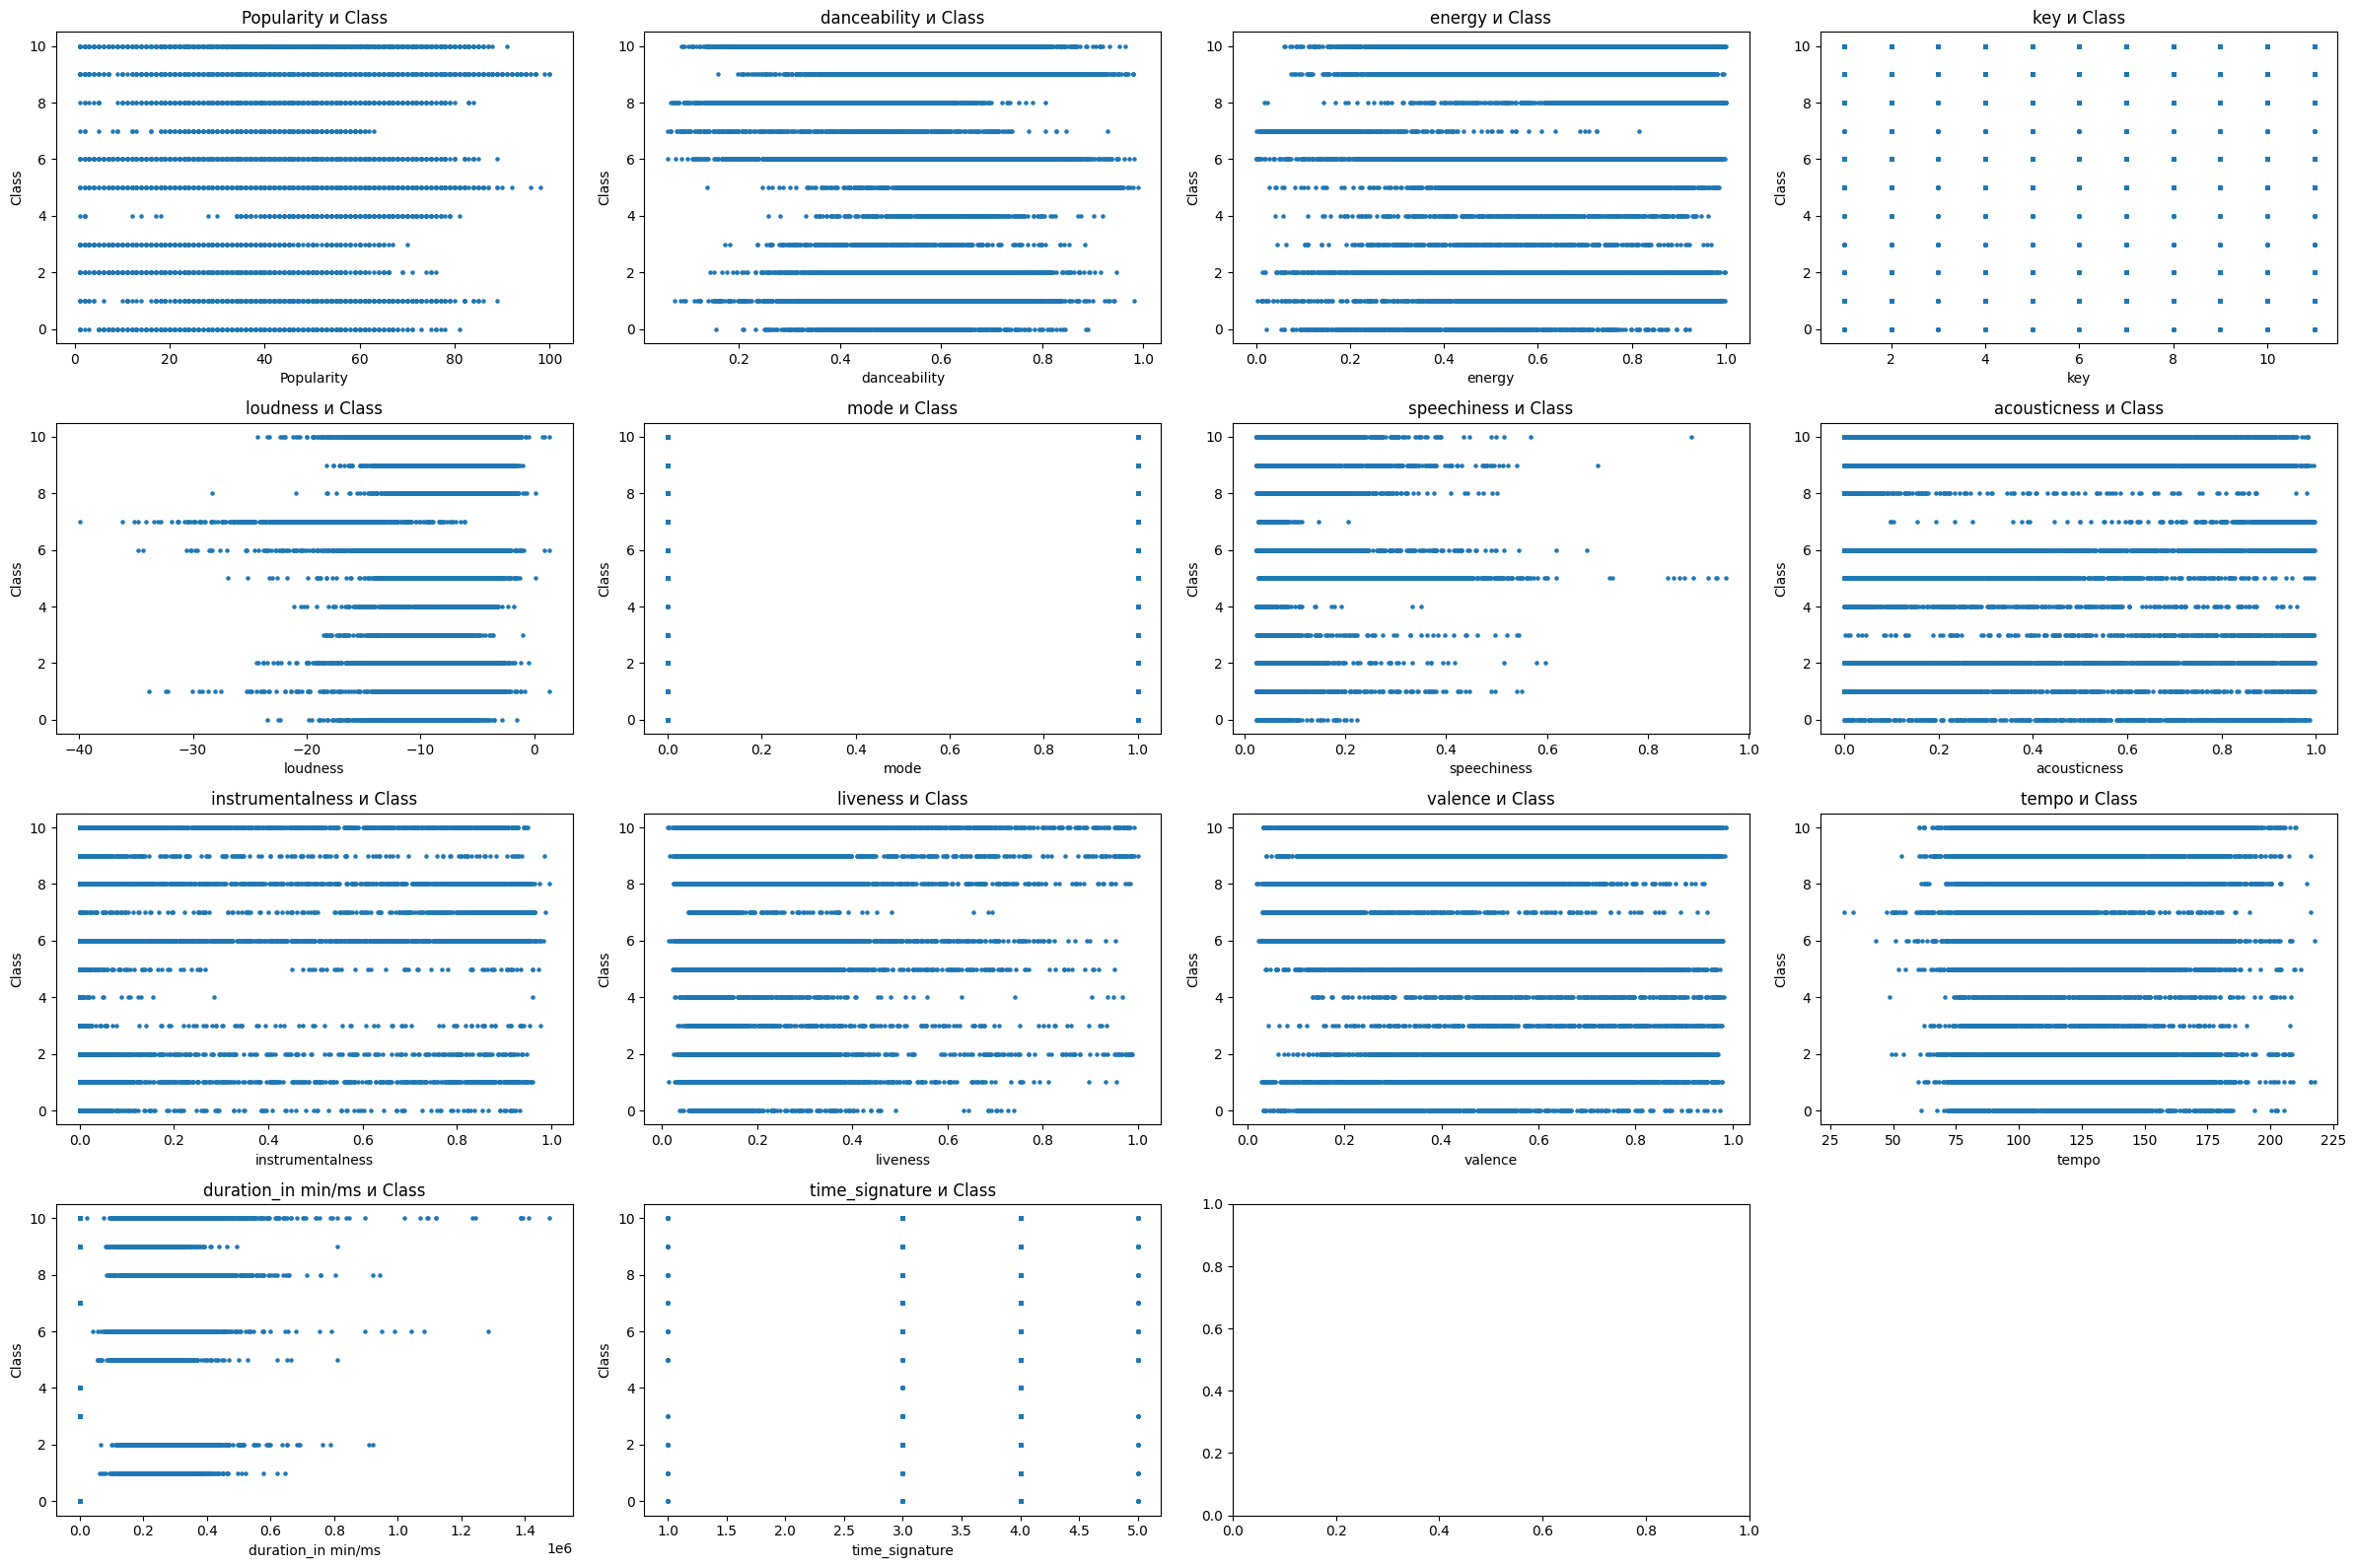

In [213]:
# Построение диаграмм рассеивания
import matplotlib.pyplot as plt
import math

n = len(num_cols) - 1
cols = 4                    
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel()  

for i, col in enumerate(num_cols):
    if col != "Class":
        axes[i].scatter(data[col], data['Class'], s = 5)
        axes[i].set_title(f"{col} и Class")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Class")


for j in range(i+1, rows*cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

2.4 Матрица корреляций

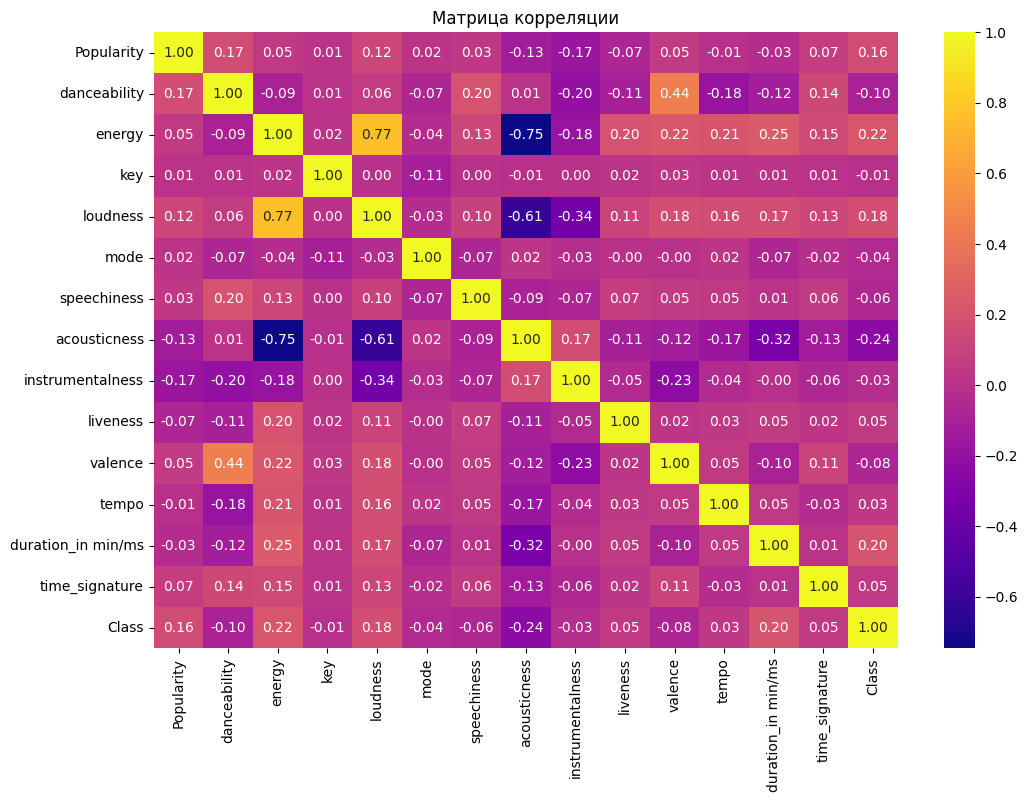

In [214]:
corr_matrix_numeric = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_numeric, annot= True, cmap='plasma', fmt='.2f')
plt.title("Матрица корреляции")
plt.show()

2.5 Высокая положительная корреляция следующих параметров композиции:
- energy
- loudness

Интерпретация: более энергичная музыка обычно более громкая

Высокая отрицательная корелляция следующих параметров композиции:
- acousticness и loudness
- acousticness и energy

Интерпретация: композиции с хорошей акустикой чаще менее энергичные и громкие

# 3. Обработка пропущенных значений

In [215]:
missing_percent = data.isna().mean() * 100
print("\nПропущенные значения (%):")
print(missing_percent.sort_values(ascending=False))


Пропущенные значения (%):
instrumentalness      24.322072
key                   11.191376
Popularity             2.378306
danceability           0.000000
energy                 0.000000
loudness               0.000000
mode                   0.000000
speechiness            0.000000
acousticness           0.000000
liveness               0.000000
valence                0.000000
tempo                  0.000000
duration_in min/ms     0.000000
time_signature         0.000000
Class                  0.000000
dtype: float64


In [216]:
data_with_nulls = data[data['instrumentalness'].isnull() | data['key'].isnull() | data['Popularity'].isnull()]

In [217]:
data_with_nulls.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,5755.000000,6183.000000,6183.000000,4169.000000,6183.000000,6183.000000,6183.000000,6183.000000,1806.000000,6183.000000,6183.000000,6183.000000,6.183000e+03,6183.000000,6183.000000
mean,47.409383,0.578758,0.648394,5.895419,-7.327658,0.661168,0.096138,0.260672,0.168212,0.198222,0.516956,122.039909,1.774354e+05,3.943555,6.835678
std,18.739583,0.160969,0.220795,3.278734,3.586483,0.473351,0.105556,0.293234,0.305527,0.158184,0.228364,29.832094,1.001613e+05,0.319054,3.122565
min,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.023000,0.000002,0.000001,0.021900,0.022300,47.387000,5.339167e-01,1.000000,0.000000
25%,34.000000,0.473000,0.502000,3.000000,-8.809000,0.000000,0.035300,0.016600,0.000054,0.098600,0.345000,97.595000,1.500365e+05,4.000000,5.000000
50%,47.000000,0.579000,0.675000,6.000000,-6.565000,1.000000,0.050000,0.129000,0.002010,0.133000,0.509000,120.151000,1.946430e+05,4.000000,8.000000
75%,61.000000,0.691000,0.825000,9.000000,-4.967500,1.000000,0.102000,0.449500,0.145750,0.262000,0.697000,142.040000,2.303130e+05,4.000000,10.000000
max,100.000000,0.974000,0.998000,11.000000,0.943000,1.000000,0.955000,0.995000,0.964000,1.000000,0.986000,209.840000,1.392667e+06,5.000000,10.000000


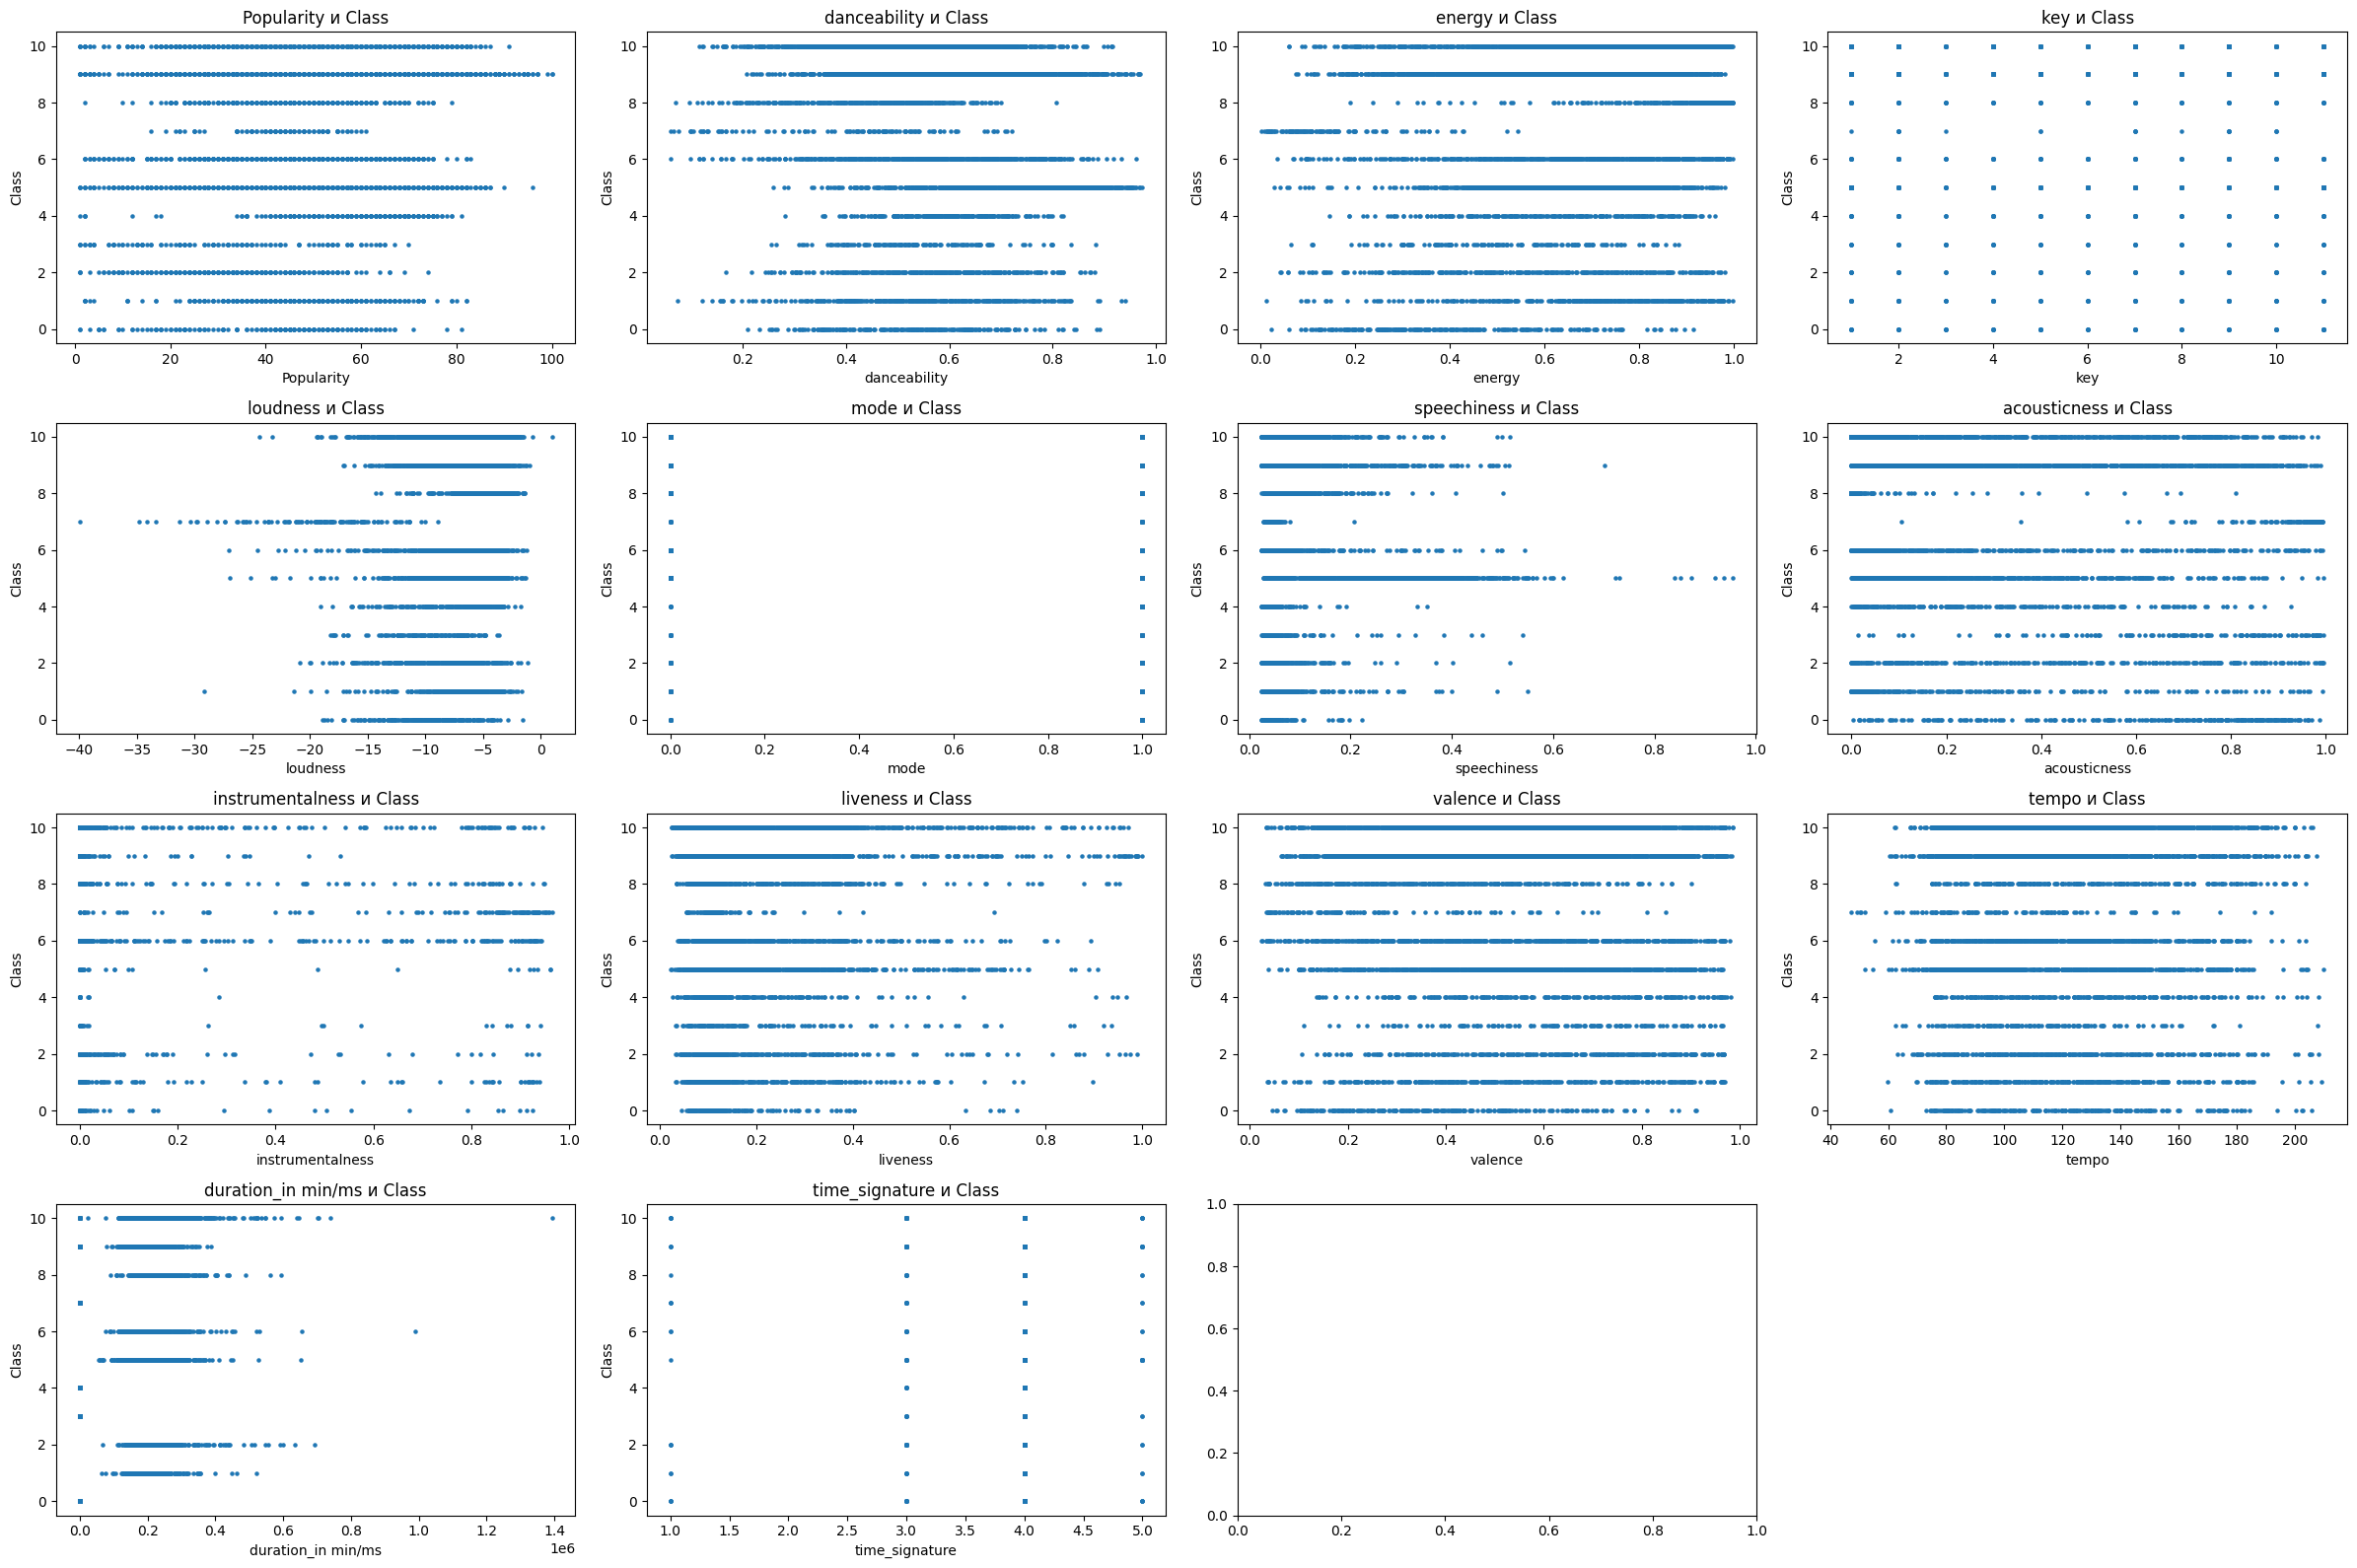

In [218]:
# Построение диаграмм рассеивания
import matplotlib.pyplot as plt
import math

n = len(num_cols) - 1
cols = 4                    
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = axes.ravel()  

for i, col in enumerate(num_cols):
    if col != "Class":
        axes[i].scatter(data_with_nulls[col], data_with_nulls['Class'], s = 5)
        axes[i].set_title(f"{col} и Class")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Class")


for j in range(i+1, rows*cols):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Диаграммы идентичны полученным по полному набору данных, поэтому можно избавиться от лишних(неполных) строк.

In [219]:
data = data.dropna(subset=['instrumentalness', 'key', 'Popularity'])

In [220]:
missing_percent = data.isna().mean() * 100
print("\nПропущенные значения (%):")
print(missing_percent.sort_values(ascending=False))


Пропущенные значения (%):
Popularity            0.0
danceability          0.0
energy                0.0
key                   0.0
loudness              0.0
mode                  0.0
speechiness           0.0
acousticness          0.0
instrumentalness      0.0
liveness              0.0
valence               0.0
tempo                 0.0
duration_in min/ms    0.0
time_signature        0.0
Class                 0.0
dtype: float64


# 4. Обработка категориальных признаков
Столбец жанра, является закодированным с помощью нумерованного списка. Нужно перевести его в OneHotEncoder.

In [221]:
# Кодирование категориальных признаков
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

copy = data.copy()

encoded_ndarr = encoder.fit_transform(copy[["Class"]])

encoded_data_cat = pd.DataFrame(
    encoded_ndarr,
    columns = ['Rock', 'Indie', 'Alt', 'Pop', 'Metal', 'HipHop', 'Alt_Music', 'Blues', 'Acoustic/Folk', 'Instrumental', 'Country'],
    index = copy.index
)

encoded_data_cat.head()

encoded_data = pd.concat([copy[num_cols], encoded_data_cat], axis=1)

encoded_data.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Indie,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country
1,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,53.0,0.235,0.977,6.0,0.878,1,0.1070,0.003530,0.006040,0.1720,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,48.0,0.674,0.658,5.0,-9.647,0,0.1040,0.404000,0.000001,0.0981,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [222]:
data = encoded_data

# 5. Нормализация числовых признаков

In [223]:
# номализация числовых признаков
scaler = StandardScaler()

num_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols.remove("Class")

encoded_and_normalized_data = encoded_data.copy()
encoded_and_normalized_data[num_cols] = scaler.fit_transform(encoded_data[num_cols])

encoded_and_normalized_data = pd.DataFrame(
    encoded_and_normalized_data,
    columns=encoded_and_normalized_data.columns,
    index=encoded_data.index
)

encoded_and_normalized_data.head()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Indie,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country
1,0.657863,-0.861080,0.593013,-0.938545,0.232529,0.776294,-0.450090,-0.748501,-0.575982,-0.589070,...,-0.310213,-0.296739,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,1.581514
2,-0.488940,-0.547837,-0.232364,0.008660,-0.027879,0.776294,-0.274522,0.770948,-0.588537,1.245203,...,-0.310213,-0.296739,-0.152941,-0.112639,-0.213936,2.189412,-0.2022,-0.384718,-0.320275,-0.632306
4,0.597505,-2.156218,1.257441,-1.254280,0.928601,0.776294,2.137688,-0.751419,-0.536186,-0.144588,...,-0.310213,-0.296739,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,1.581514
5,0.597505,-1.746593,1.265694,0.008660,2.145018,0.776294,0.529548,-0.740887,-0.569300,-0.144588,...,-0.310213,-0.296739,-0.152941,-0.112639,-0.213936,2.189412,-0.2022,-0.384718,-0.320275,-0.632306
6,0.295715,0.897898,-0.050781,-0.307075,-0.337585,-1.288172,0.485287,0.513999,-0.589178,-0.607225,...,-0.310213,3.369970,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,-0.632306


# 6. Разбиение данных на обучающую и тестовую выборки

In [224]:
#  X - признаки, Y - вектор целевой переменной
X = encoded_and_normalized_data.drop("Class", axis = 1)
Y = encoded_and_normalized_data["Class"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 1
)

# 7-9. Регрессия ближайших соседей

In [225]:
# Перебираем параметр k
k_values = range(1, 100)
train_mse = []
test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)

    train_mse.append(mean_squared_error(Y_train, knn.predict(X_train)))
    test_mse.append(mean_squared_error(Y_test, knn.predict(X_test)))

In [226]:
best_k = test_mse.index(min(test_mse)) + 1
print("Лучшее значение k: ", best_k)
print("Лучшее значение ошибки на тренировочной выборке:", train_mse[k - 1])
print("Лучшее значение ошибки на тестовой выборке:", test_mse[k - 1])

Лучшее значение k:  2
Лучшее значение ошибки на тренировочной выборке: 0.035010821161213984
Лучшее значение ошибки на тестовой выборке: 0.06334205578874015


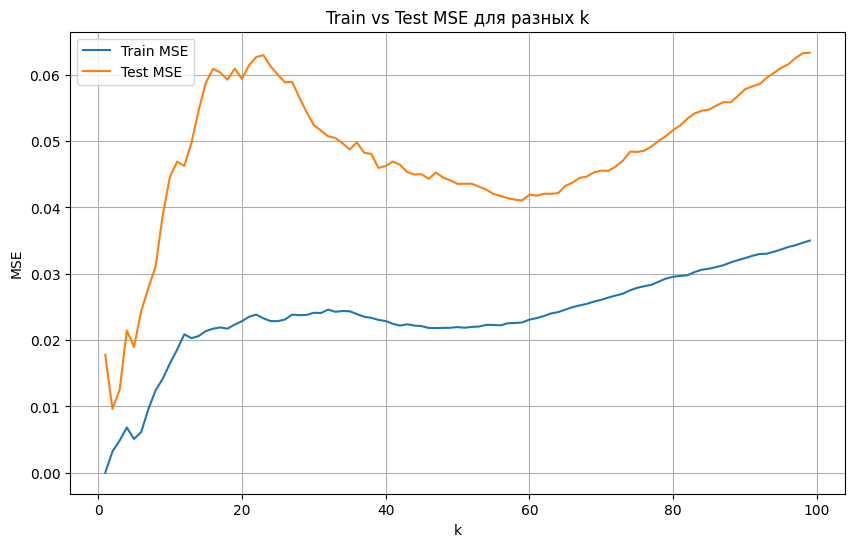

In [227]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_mse, label='Train MSE')
plt.plot(k_values, test_mse, label='Test MSE')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("Train vs Test MSE для разных k")
plt.legend()
plt.grid(True)
plt.show()

# 10. Другие методы регресии
10.1 Линейная регрессия(метод наименьших квадратов)

In [228]:
lin = LinearRegression()
lin.fit(X_train, Y_train)

train_err_lin = (mean_squared_error(Y_train, lin.predict(X_train)))
test_err_lin  = (mean_squared_error(Y_test, lin.predict(X_test)))

print("Ошибка на тренировочной выборке: ",train_err_lin)
print("Ошибка на тестовой выборке: ",test_err_lin)

Ошибка на тренировочной выборке:  2.2092293821947004e-28
Ошибка на тестовой выборке:  2.310204031924684e-28


10.2 Дерево решений

In [229]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, Y_train)

train_err_tree = (mean_squared_error(Y_train, tree.predict(X_train)))
test_err_tree  = (mean_squared_error(Y_test, tree.predict(X_test)))

# Дерево без настройки параметров
print(train_err_tree)
print(test_err_tree)

tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20, 40]
}

from sklearn.model_selection import GridSearchCV

# Дерево с подбором параметров
grid = GridSearchCV(tree, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, Y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая средняя ошибка (cv MSE):", -grid.best_score_)

# Лучшее дерево
best_tree = grid.best_estimator_

train_err_best = mean_squared_error(Y_train, best_tree.predict(X_train))
test_err_best  = mean_squared_error(Y_test,  best_tree.predict(X_test))

print("Ошибка на тренировочной выборке (лучшее дерево):", train_err_best)
print("Ошибка на тестовой выборке (лучшее дерево):", test_err_best)

0.0
0.0
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая средняя ошибка (cv MSE): -0.0
Ошибка на тренировочной выборке (лучшее дерево): 0.0
Ошибка на тестовой выборке (лучшее дерево): 0.0


# 11. Борьба с несбалансированностью классов

Распределение классов:
Class
10    3374
6     2039
8     1523
9     1099
1     1037
2      956
5      517
7      464
0      386
3      270
4      148
Name: count, dtype: int64


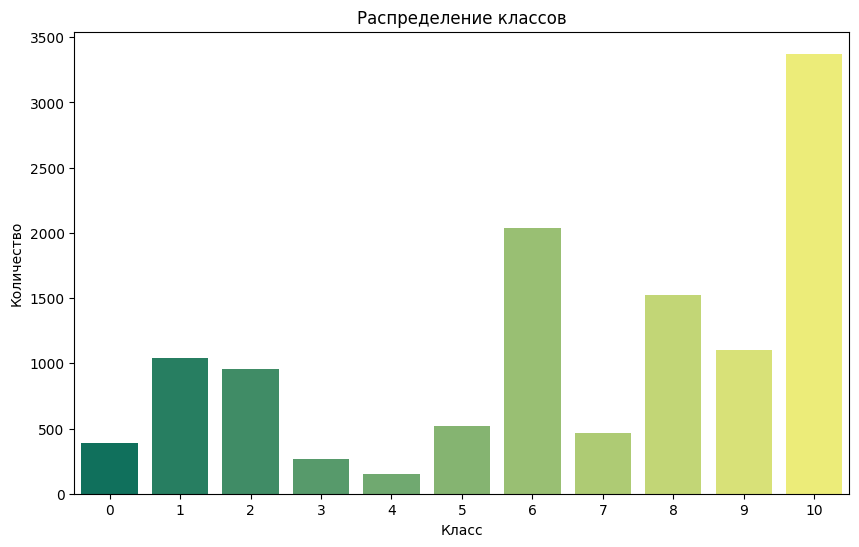

In [230]:
class_distribution = encoded_and_normalized_data['Class'].value_counts()
print("Распределение классов:")
print(class_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values,
            hue=class_distribution.index, palette='summer', legend=False)
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

In [231]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

In [232]:
#  X - признаки, Y - вектор целевой переменной
X = encoded_and_normalized_data.drop("Class", axis = 1)
Y = encoded_and_normalized_data["Class"]

print(Y)

print("До SMOTE:", Counter(Y))

smoteenn = SMOTE(random_state=42)
X_smote, Y_smote = smoteenn.fit_resample(X, Y)

print("После SMOTE:", Counter(Y_smote))

1        10
2         6
4        10
5         6
6         2
         ..
17991     6
17992     2
17993     8
17994     8
17995    10
Name: Class, Length: 11813, dtype: int64
До SMOTE: Counter({10: 3374, 6: 2039, 8: 1523, 9: 1099, 1: 1037, 2: 956, 5: 517, 7: 464, 0: 386, 3: 270, 4: 148})
После SMOTE: Counter({10: 3374, 6: 3374, 2: 3374, 4: 3374, 8: 3374, 3: 3374, 7: 3374, 9: 3374, 1: 3374, 5: 3374, 0: 3374})


# 12. Исключение коррелированных переменных

Исключение высококоррелированных переменных может:
- уменьшить мультиколлинеарность
- стабилизировать коэффициенты и улучшить обобщающую способность моделей, склонных к переобучению
- сократить размерность признакового пространства.

12.1 Удаление высококоррелированных переменных

In [233]:
# to_drop = ['acousticness']
to_drop = ['loudness', 'energy']

#X_smote = X_smote.drop(columns = to_drop)

# Получаем уменьшенный массив
data_reduced = X_smote.join(Y_smote, how='left')
data_reduced.info()
data_reduced.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37114 entries, 0 to 37113
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Popularity          37114 non-null  float64
 1   danceability        37114 non-null  float64
 2   energy              37114 non-null  float64
 3   key                 37114 non-null  float64
 4   loudness            37114 non-null  float64
 5   mode                37114 non-null  float64
 6   speechiness         37114 non-null  float64
 7   acousticness        37114 non-null  float64
 8   instrumentalness    37114 non-null  float64
 9   liveness            37114 non-null  float64
 10  valence             37114 non-null  float64
 11  tempo               37114 non-null  float64
 12  duration_in min/ms  37114 non-null  float64
 13  time_signature      37114 non-null  float64
 14  Rock                37114 non-null  float64
 15  Indie               37114 non-null  float64
 16  Alt 

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,Alt,Pop,Metal,HipHop,Alt_Music,Blues,Acoustic/Folk,Instrumental,Country,Class
0,0.657863,-0.861080,0.593013,-0.938545,0.232529,0.776294,-0.450090,-0.748501,-0.575982,-0.589070,...,-0.296739,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,1.581514,10
1,-0.488940,-0.547837,-0.232364,0.008660,-0.027879,0.776294,-0.274522,0.770948,-0.588537,1.245203,...,-0.296739,-0.152941,-0.112639,-0.213936,2.189412,-0.2022,-0.384718,-0.320275,-0.632306,6
2,0.597505,-2.156218,1.257441,-1.254280,0.928601,0.776294,2.137688,-0.751419,-0.536186,-0.144588,...,-0.296739,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,1.581514,10
3,0.597505,-1.746593,1.265694,0.008660,2.145018,0.776294,0.529548,-0.740887,-0.569300,-0.144588,...,-0.296739,-0.152941,-0.112639,-0.213936,2.189412,-0.2022,-0.384718,-0.320275,-0.632306,6
4,0.295715,0.897898,-0.050781,-0.307075,-0.337585,-1.288172,0.485287,0.513999,-0.589178,-0.607225,...,3.369970,-0.152941,-0.112639,-0.213936,-0.456744,-0.2022,-0.384718,-0.320275,-0.632306,2


12.2 Разбиваем уменьшенные данные на тестовую и тренировочную выборки

In [234]:
X = data_reduced.drop("Class", axis = 1)
Y = data_reduced["Class"]

print(Y)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 1
)

0        10
1         6
2        10
3         6
4         2
         ..
37109     9
37110     9
37111     9
37112     9
37113     9
Name: Class, Length: 37114, dtype: int64


12.3 Тест kNN

In [235]:
k_values = range(1, 100)
train_mse = []
test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)

    train_mse.append(mean_squared_error(Y_train, knn.predict(X_train)))
    test_mse.append(mean_squared_error(Y_test, knn.predict(X_test)))

best_k = test_mse.index(min(test_mse)) + 1
print("Лучшее значение k: ", best_k)
print("Лучшее значение ошибки на тренировочной выборке:", train_mse[k - 1])
print("Лучшее значение ошибки на тестовой выборке:", test_mse[k - 1])

Лучшее значение k:  2
Лучшее значение ошибки на тренировочной выборке: 0.014556306860984433
Лучшее значение ошибки на тестовой выборке: 0.01786586343185611


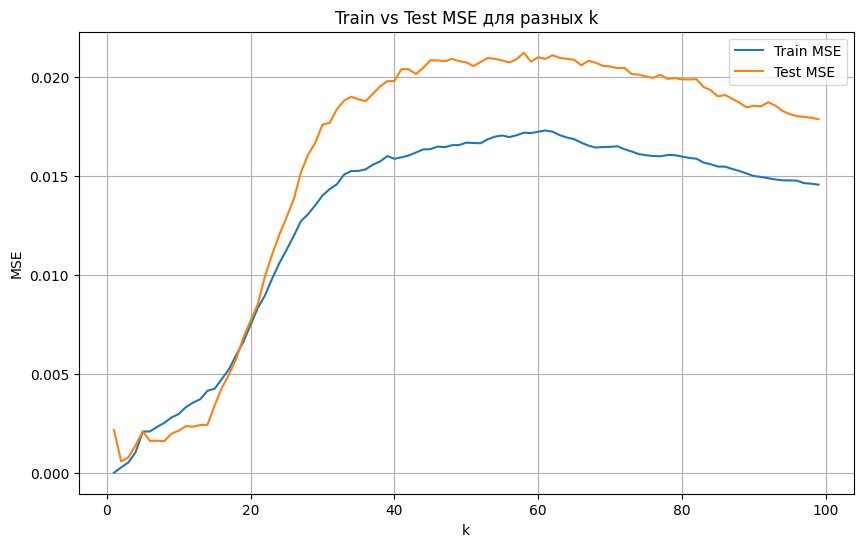

In [236]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_mse, label='Train MSE')
plt.plot(k_values, test_mse, label='Test MSE')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("Train vs Test MSE для разных k")
plt.legend()
plt.grid(True)
plt.show()

12.4 Тест LinRegression

In [237]:
lin = LinearRegression()
lin.fit(X_train, Y_train)

train_err_lin = (mean_squared_error(Y_train, lin.predict(X_train)))
test_err_lin  = (mean_squared_error(Y_test, lin.predict(X_test)))

print("Ошибка на тренировочной выборке: ",train_err_lin)
print("Ошибка на тестовой выборке: ",test_err_lin)

Ошибка на тренировочной выборке:  3.326557437560486e-29
Ошибка на тестовой выборке:  3.370316026146928e-29


12.5 Тест дерева решения

In [238]:
tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20, 40]
}

from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(tree, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, Y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая средняя ошибка (cv MSE):", -grid.best_score_)

best_tree = grid.best_estimator_

train_err_best = mean_squared_error(Y_train, best_tree.predict(X_train))
test_err_best  = mean_squared_error(Y_test,  best_tree.predict(X_test))

print("Ошибка на тренировочной выборке (лучшее дерево):", train_err_best)
print("Ошибка на тестовой выборке (лучшее дерево):", test_err_best)

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая средняя ошибка (cv MSE): -0.0
Ошибка на тренировочной выборке (лучшее дерево): 0.0
Ошибка на тестовой выборке (лучшее дерево): 0.0


# 13. Выводы

### Используемая метрика: MSE(Mean Squared Error)
1. Метод KNN показал худшую скорость и умеренное качество из-за высокой размерности признаков.
Высокая размерность после one-hot кодирования ухудшила различимость расстояний, что типично для KNN. Время работы KNN пропорционально количеству признаков и объёму данных, поэтому он обучается и делает подбор k значительно медленнее остальных моделей.
До удаления коррелирующих переменных:
best k = 2

Train error = 0.0350

Test error = 0.0633

После удаления коррелирующих переменных:
best k = 2

Train error = 0.01456

Test error = 0.01787

2. Линейная регрессия дала более хороший результат, что указывает на близкую к линейной зависимость между признаками и целевой переменной(что видно по диаграммам рассеивания числовых переменных жанра).
Стандартизация признаков положительно влияет на устойчивость решения.
До удаления коррелирующих переменных:
Train error = 2.2092e-28

Test error = 2.3102e-28

После удаления коррелирующих переменных:
Train error = 3.3265e-29

Test error = 3.3703e-29

3. Дерево решений дало наилучший результат.
Train MSE = 0.0

Test MSE = 0.0

CV MSE = 0.0

После удаления коррелирующих переменных:
Train MSE = 0.0

Test MSE = 0.0

CV MSE = 0.0

4. Удаление сильно коррелированных между собой признаков улучшило качество всех трёх моделей и сократило размерность данных. Это поспособствовало:
- ускорению обучения

- упрощению модели

- улучшению интерпретируемости данных

Итог:
Лучшая модель для этих данных: Дерево решений, из чего можно сделать следующий вывод: в наборе данных отсутствуют выбросы и присутствуют малозначимые параметры, переобучение на которых оно избегает.
Линейная регрессия при подходящих параметрах показывает результат немного хуже Дерева решений
Удаление сильно коррелированных между собой признаков не ухудшило качество ни одной модели и в большинстве случаев слегка улучшило его, что видно по соответствующим метрикам.